In [2]:
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time

In [3]:
# Set the Seaborn theme
sns.set_theme(style="darkgrid")

Get the Lat/long

In [3]:
df_merged= pd.read_csv('merged_city_damage_mmi_latlon.csv')
df_merged.drop(columns=['MMI_numeric','damage_level_avg'], inplace=True)
df = pd.read_csv('result_gemini_final.csv')
merged = pd.merge(df, df_merged, on='location_response_city')
print(merged.head())


   Unnamed: 0            user        user_name  \
0           1      theterbush    Brian Terbush   
1          16  ClassyEarlGrey           Monica   
2          20          wspusa          WSP USA   
3          24  kierondonoghue  Kieron Donoghue   
4          25        KFoleyFL       Kyle Foley   

                                         description  verified  \
0  Volcano Geophysicist turned Earthquake/Volcano...     False   
1  Read Rama the Gypsy Cat and never stopped wand...     False   
2  WSP in the USA serves clients in property and ...     False   
3  Founder @HumbleAngelRecs. Formerly Warner Musi...      True   
4  Lake Nona High School Percussion Instructor, P...      True   

                          created          time         location  latitude_x  \
0  Wed Nov 15 16:54:15 +0000 2017  1.562210e+12  Washington, USA         NaN   
1  Tue Sep 20 12:01:36 +0000 2016  1.562250e+12    Snohomish, WA         NaN   
2  Thu May 07 13:24:16 +0000 2015  1.562250e+12    United Stat

/var/folders/16/1vd8ng7110b2d_r29trv5qwh0000gn/T/ipykernel_82310/1919471373.py:3: DtypeWarning: Columns (20,24,25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('result_gemini_final.csv')


In [6]:
merged.drop(columns=['latitude_x','longitude_x'], inplace=True)
print(merged.head())

   Unnamed: 0            user        user_name  \
0           1      theterbush    Brian Terbush   
1          16  ClassyEarlGrey           Monica   
2          20          wspusa          WSP USA   
3          24  kierondonoghue  Kieron Donoghue   
4          25        KFoleyFL       Kyle Foley   

                                         description  verified  \
0  Volcano Geophysicist turned Earthquake/Volcano...     False   
1  Read Rama the Gypsy Cat and never stopped wand...     False   
2  WSP in the USA serves clients in property and ...     False   
3  Founder @HumbleAngelRecs. Formerly Warner Musi...      True   
4  Lake Nona High School Percussion Instructor, P...      True   

                          created          time         location  place  \
0  Wed Nov 15 16:54:15 +0000 2017  1.562210e+12  Washington, USA    NaN   
1  Tue Sep 20 12:01:36 +0000 2016  1.562250e+12    Snohomish, WA    NaN   
2  Thu May 07 13:24:16 +0000 2015  1.562250e+12    United States    NaN   
3 

In [20]:
# Step 1: Setup geolocator
geolocator = Nominatim(user_agent="city_reverse_geocoder")
reverse = RateLimiter(geolocator.reverse, min_delay_seconds=1)

In [21]:
# Step 2: Extract unique city + lat/long
city_coords = merged[['location_response_city', 'latitude_y', 'longitude_y']].dropna().drop_duplicates()
city_to_county = {}

In [22]:
print(city_coords.head())

   location_response_city  latitude_y  longitude_y
0              Washington   39.359342  -120.799108
1               Snohomish   47.980078  -122.198125
3             Los Angeles   34.053691  -118.242766
9             North Hills   34.242958  -118.485408
10         Marina del Rey   33.977685  -118.448647


In [23]:

# Step 3: Reverse geocode each unique city's coordinates
for _, row in city_coords.iterrows():
    city = row['location_response_city']
    lat, lon = row['latitude_y'], row['longitude_y']
    try:
        location = reverse((lat, lon), exactly_one=True)
        county = location.raw['address'].get('county') if location else None
        city_to_county[city] = county
    except Exception as e:
        city_to_county[city] = None

In [24]:

# Step 4: Map back to full DataFrame
merged['county'] = merged['location_response_city'].map(city_to_county)

In [25]:
merged.to_csv('merged.csv', index=False)

In [5]:
# Group by county and calculate mean values
county_data = merged.groupby('county', as_index=False).agg({
    'damage_level': 'mean'
}).dropna()  # Remove any rows with NaN values

In [6]:
#drop some counties tweets less than 10 
# Step 1: Count tweets per county
county_counts = merged['county'].value_counts()

# Step 2: Get list of counties with >= 10 tweets
valid_counties = county_counts[county_counts >= 10].index

# Step 3: Filter the DataFrame
df_filtered = merged[merged['county'].isin(valid_counties)].copy()

print(len(df_filtered))


14358


DYFI survey

In [29]:
df2 = pd.read_csv('/Users/zihuima/Desktop/LLM_earthquake/2019_ridgecrest_DYFI.csv', dtype={'Zip Code': str})
# Roman numeral to integer mapping for MMI scale
mmi_mapping = {
    'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'V': 5,
    'VI': 6, 'VII': 7, 'VIII': 8, 'IX': 9, 'X': 10,
    'XI': 11, 'XII': 12
}

# Apply the mapping to the MMI column
df2['MMI_numeric'] = df2['MMI'].map(mmi_mapping)

In [43]:
# Step 2: Extract unique city + lat/long
city_coords_1 = df2[['City', 'Latitude', 'Longitude']].dropna().drop_duplicates()
city_to_county_1 = {}

In [45]:

# Step 3: Reverse geocode each unique city's coordinates
for _, row in city_coords_1.iterrows():
    city = row['City']
    lat, lon = row['Latitude'], row['Longitude']
    try:
        location = reverse((lat, lon), exactly_one=True)
        county = location.raw['address'].get('county') if location else None
        city_to_county_1[city] = county
    except Exception as e:
        city_to_county_1[city] = None

In [46]:

# Step 4: Map back to full DataFrame
df2['county'] = df2['City'].map(city_to_county)
print(df2.columns)

Index(['City', 'State/Region', 'Country', 'Zip Code', 'MMI', 'Responses',
       'Distance', 'Latitude', 'Longitude', 'MMI_numeric', 'county'],
      dtype='object')


In [49]:
df2.to_csv('DYFI_county.csv', index=False)

In [8]:
#List of California counties
ca_counties = [
    'Alameda County', 'Alpine County', 'Amador County', 'Butte County', 'Calaveras County',
    'Colusa County', 'Contra Costa County', 'Del Norte County', 'El Dorado County', 'Fresno County',
    'Glenn County', 'Humboldt County', 'Imperial County', 'Inyo County', 'Kern County',
    'Kings County', 'Lake County', 'Lassen County', 'Los Angeles County', 'Madera County',
    'Marin County', 'Mariposa County', 'Mendocino County', 'Merced County', 'Modoc County',
    'Mono County', 'Monterey County', 'Napa County', 'Nevada County', 'Orange County',
    'Placer County', 'Plumas County', 'Riverside County', 'Sacramento County', 'San Benito County',
    'San Bernardino County', 'San Diego County', 'San Francisco County', 'San Joaquin County',
    'San Luis Obispo County', 'San Mateo County', 'Santa Barbara County', 'Santa Clara County',
    'Santa Cruz County', 'Shasta County', 'Sierra County', 'Siskiyou County', 'Solano County',
    'Sonoma County', 'Stanislaus County', 'Sutter County', 'Tehama County', 'Trinity County',
    'Tulare County', 'Tuolumne County', 'Ventura County', 'Yolo County', 'Yuba County'
]

# Filter for California counties
ca_data = df_filtered [df_filtered['county'].isin(ca_counties)]

# Group by county and calculate mean values
county_data = ca_data.groupby('county', as_index=False).agg({
    'damage_level': 'mean'
}).dropna()  # Remove a

In [9]:
# Filter for California counties
# First, let's see what counties we have
print("All counties in the dataset:")
print(df_filtered['county'].unique())

All counties in the dataset:
['Nevada County' 'Los Angeles County' 'Kern County' 'Santa Barbara County'
 'Ventura County' 'Riverside County' 'Orange County' 'Fresno County'
 'San Bernardino County' 'Contra Costa County' 'Inyo County'
 'Lassen County' 'Stanislaus County' 'Alameda County' 'San Diego County'
 'Sacramento County' 'Siskiyou County' 'Nye County' 'Monterey County'
 'Tuolumne County' 'Santa Clara County' 'Tulare County'
 'Santa Cruz County' 'San Luis Obispo County' 'San Mateo County'
 'Mariposa County' 'Placer County' 'Merced County' 'Salt Lake County'
 'Butte County' 'Kings County' 'Sonoma County' 'Solano County'
 'San Joaquin County' 'Imperial County' 'Marin County']


In [10]:
 #Group by city: average damage_level from LLM
gemini_city = df_filtered.groupby('county', as_index=False)['damage_level'].mean()

# Group by city: average MMI from DYFI (using numeric MMI)
dyfi_city = df2.groupby('county', as_index=False)['MMI_numeric'].mean()

# Merge on city name (adjust column names if needed)
merged_1 = pd.merge(gemini_city, dyfi_city, on='county')

In [11]:
print(merged_1.head())

                county  damage_level  MMI_numeric
0       Alameda County      2.963964     1.852941
1         Butte County      3.083333     2.000000
2  Contra Costa County      3.024390     1.937500
3        Fresno County      2.788462     3.454545
4      Imperial County      2.846154     3.000000


County_level correlation

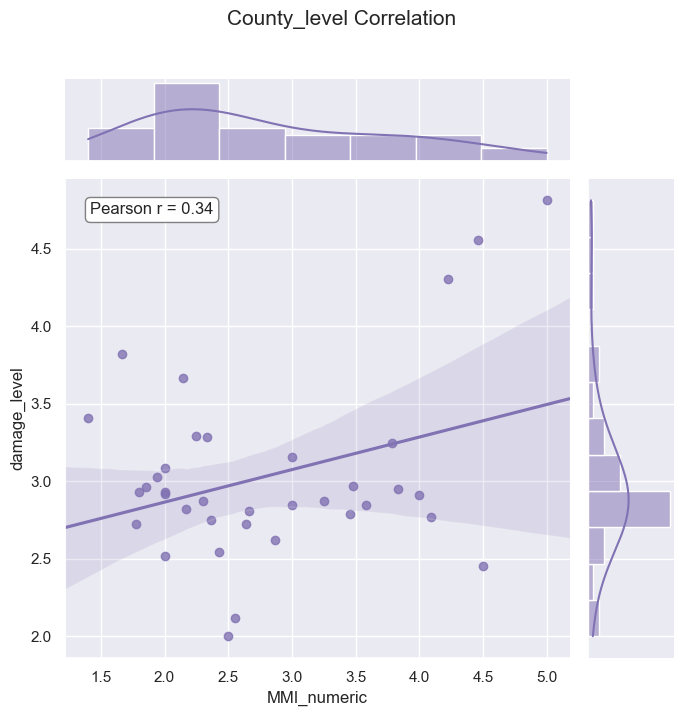

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

def annotate_corr_scatter(x, y, ax, label="Pearson r"):
    # Remove NaNs for correlation calculation
    mask = (~pd.isnull(x)) & (~pd.isnull(y))
    r, pval = pearsonr(x[mask], y[mask])
    ax.annotate(f"{label} = {r:.2f}", #\np-value = {pval:.2e}"  for p-value
                xy=(0.05, 0.95),
                xycoords='axes fraction',
                ha='left', va='top',
                fontsize=12,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1))

# Create the jointplot
g = sns.jointplot(
    x="MMI_numeric",
    y="damage_level",
    data=merged_1,
    kind="reg",
    truncate=False,
    color="m",
    height=7
)


# Add title
plt.suptitle("County_level Correlation", fontsize=15, y=1.02)

# Add correlation annotation using our function
annotate_corr_scatter(merged_1['MMI_numeric'], merged_1['damage_level'], g.ax_joint)


plt.tight_layout()
plt.show()

Adjust damage value 

In [13]:
#Calculate absolute difference between MMI_numeric and damage_level
merged_1['abs_diff'] = abs(merged_1['MMI_numeric'] - merged_1['damage_level'])

# Create a copy of the data
adjusted_data = merged_1.copy()

# For points where difference < 1, set damage_level = MMI_numeric
adjusted_data.loc[adjusted_data['abs_diff'] < 1, 'damage_level'] = adjusted_data.loc[adjusted_data['abs_diff'] < 1, 'MMI_numeric']


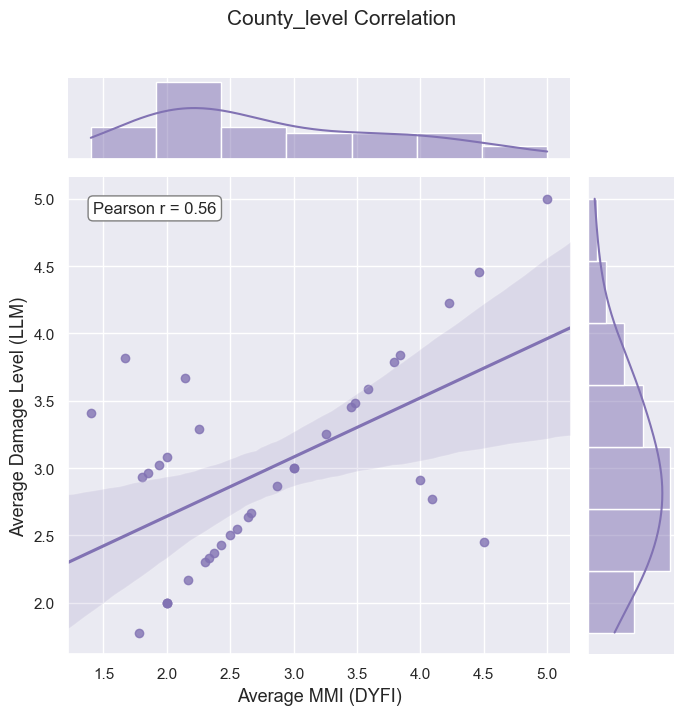

In [14]:
# Create the jointplot
g = sns.jointplot(
    x="MMI_numeric",
    y="damage_level",
    data=adjusted_data,
    kind="reg",
    truncate=False,
    color="m",
    height=7
)

# Set axis labels
g.set_axis_labels("Average MMI (DYFI)", "Average Damage Level (LLM)", fontsize=13)

# Add title
plt.suptitle("County_level Correlation", fontsize=15, y=1.02)
#plt.suptitle("Correlation between MMI and Damage Level by California County\n(Values within ±1 set equal)", fontsize=15, y=1.02)

# Add correlation annotation using our function
annotate_corr_scatter(adjusted_data['MMI_numeric'], adjusted_data['damage_level'], g.ax_joint)

plt.tight_layout()
plt.show()

In [60]:
print(df_filtered.columns)

Index(['Unnamed: 0', 'user', 'user_name', 'description', 'verified', 'created',
       'time', 'location', 'place', 'text', 'unique_image_urls',
       'location_response_json', 'location_response', 'location_response_city',
       'location_response_general', 'Unnamed: 17', 'Unnamed: 18',
       'Unnamed: 19', 'Unnamed: 20', 'event_related_response_json',
       'event_related_response', 'text_only_response', 'image_only_response',
       'text_image_response', 'model_response', 'human_impact', 'damage_type',
       'damage_level', 'reasoning', 'confidence', 'Unnamed: 26', 'latitude_y',
       'longitude_y', 'county'],
      dtype='object')


City_level damage correlation 

  location_response_city  damage_level          City  MMI_numeric
0                  Acton      3.000000         Acton          4.0
1               Adelanto      3.000000      Adelanto          5.0
2           Agoura Hills      3.000000  Agoura Hills          3.0
3                Alameda      3.666667       Alameda          1.5
4                 Albany      1.000000        Albany          1.0


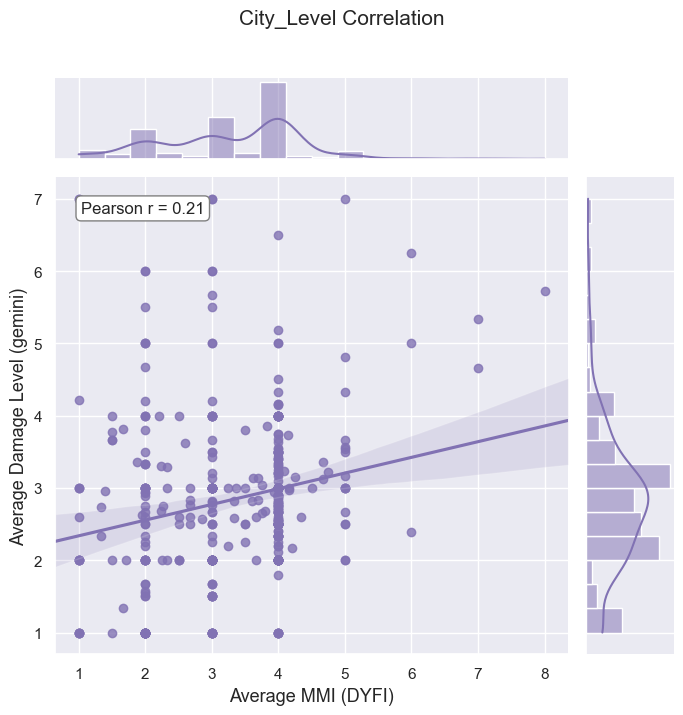

In [21]:
#Group by city: average damage_level from LLM
gemini_city_1 = df_filtered.groupby('location_response_city', as_index=False)['damage_level'].mean()

# Group by city: average MMI from DYFI (using numeric MMI)
dyfi_city_1 = df2.groupby('City', as_index=False)['MMI_numeric'].mean()

# Merge on city name (adjust column names if needed)
merged_2 = pd.merge(gemini_city_1, dyfi_city_1, left_on='location_response_city', right_on='City')

print(merged_2.head())
# Create the jointplot
g = sns.jointplot(
    x="MMI_numeric",
    y="damage_level",
    data=merged_2,  
    kind="reg",
    truncate=False,
    color="m",
    height=7
)

 #Set axis labels
g.set_axis_labels("Average MMI (DYFI)", "Average Damage Level (gemini)", fontsize=13)

# Add title
plt.suptitle("City_Level Correlation", fontsize=15, y=1.02)
#plt.suptitle("Correlation between MMI and Damage Level by California County\n(Values within ±1 set equal)", fontsize=15, y=1.02)

# Add correlation annotation using our function
annotate_corr_scatter(merged_2['MMI_numeric'], merged_2['damage_level'], g.ax_joint)

plt.tight_layout()
plt.show()


Drop cities -- final used in paper

In [18]:
#let's try to drop the outliers

# Step 1: Count tweets per county
city_counts = df_filtered['location_response_city'].value_counts()

# Step 2: Get list of counties with >= 10 tweets
valid_counties = city_counts[city_counts >= 10].index

# Step 3: Filter the DataFrame
df_filtered_1 = df_filtered[df_filtered['location_response_city'].isin(valid_counties)].copy()

print(len(df_filtered_1))

13317


In [65]:
print(city_counts)

location_response_city
Los Angeles     5830
Ridgecrest      2811
Las Vegas        993
San Diego        279
Trona            221
                ... 
Mendota            1
Ladera Ranch       1
Avalon             1
Nipomo             1
Monroe             1
Name: count, Length: 423, dtype: int64


  location_response_city  damage_level          City  MMI_numeric
0                Anaheim      2.792000       Anaheim     4.000000
1           Apple Valley      3.538462  Apple Valley     5.000000
2            Bakersfield      3.235955   Bakersfield     4.090909
3                Barstow      3.562500       Barstow     5.000000
4               Berkeley      2.962963      Berkeley     1.400000


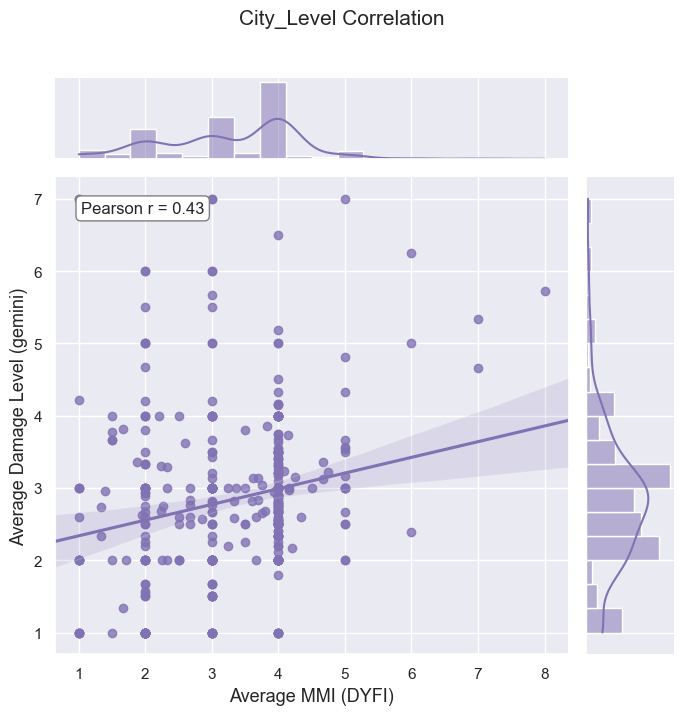

In [22]:
#Group by city: average damage_level from LLM
gemini_city_2 = df_filtered_1.groupby('location_response_city', as_index=False)['damage_level'].mean()

# Group by city: average MMI from DYFI (using numeric MMI)
dyfi_city_1 = df2.groupby('City', as_index=False)['MMI_numeric'].mean()

# Merge on city name (adjust column names if needed)
merged_3 = pd.merge(gemini_city_2, dyfi_city_1, left_on='location_response_city', right_on='City')

print(merged_3.head())
# Create the jointplot
g = sns.jointplot(
    x="MMI_numeric",
    y="damage_level",
    data=merged_2,  
    kind="reg",
    truncate=False,
    color="m",
    height=7
)

 #Set axis labels
g.set_axis_labels("Average MMI (DYFI)", "Average Damage Level (gemini)", fontsize=13)

# Add title
plt.suptitle("City_Level Correlation", fontsize=15, y=1.02)
#plt.suptitle("Correlation between MMI and Damage Level by California County\n(Values within ±1 set equal)", fontsize=15, y=1.02)

# Add correlation annotation using our function
annotate_corr_scatter(merged_3['MMI_numeric'], merged_3['damage_level'], g.ax_joint)

plt.tight_layout()
plt.show()


In [24]:
merged_3.to_csv('gemini_city_dropped.csv', index=False)